In [1]:
# ============================================================
# STEP 1: IMPORTS AND DATA LOADING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv(r'C:\Users\talha\OneDrive\Desktop\Clinical_model_work\raw\diabetes_dataset_with_notes.csv')

# Basic overview
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (100000, 17)

Column names: ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes', 'clinical_notes']

Data types:
 year                      int64
gender                   object
age                     float64
location                 object
race:AfricanAmerican      int64
race:Asian                int64
race:Caucasian            int64
race:Hispanic             int64
race:Other                int64
hypertension              int64
heart_disease             int64
smoking_history          object
bmi                     float64
hbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
clinical_notes           object
dtype: object

First 5 rows:


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


BASIC STATISTICS

Dataset Shape: (100000, 17)

Missing Values:
 year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
clinical_notes          0
dtype: int64

Duplicate Rows: 14

TARGET DISTRIBUTION
Non-Diabetic (0): 91500 (91.5%)
Diabetic     (1): 8500 (8.5%)

NUMERICAL FEATURE STATISTICS
             age        bmi  hbA1c_level  blood_glucose_level
count  100000.00  100000.00    100000.00            100000.00
mean       41.89      27.32         5.53               138.06
std        22.52       6.64         1.07                40.71
min         0.08      10.01         3.50                80.00
25%        24.00      23.63         4.

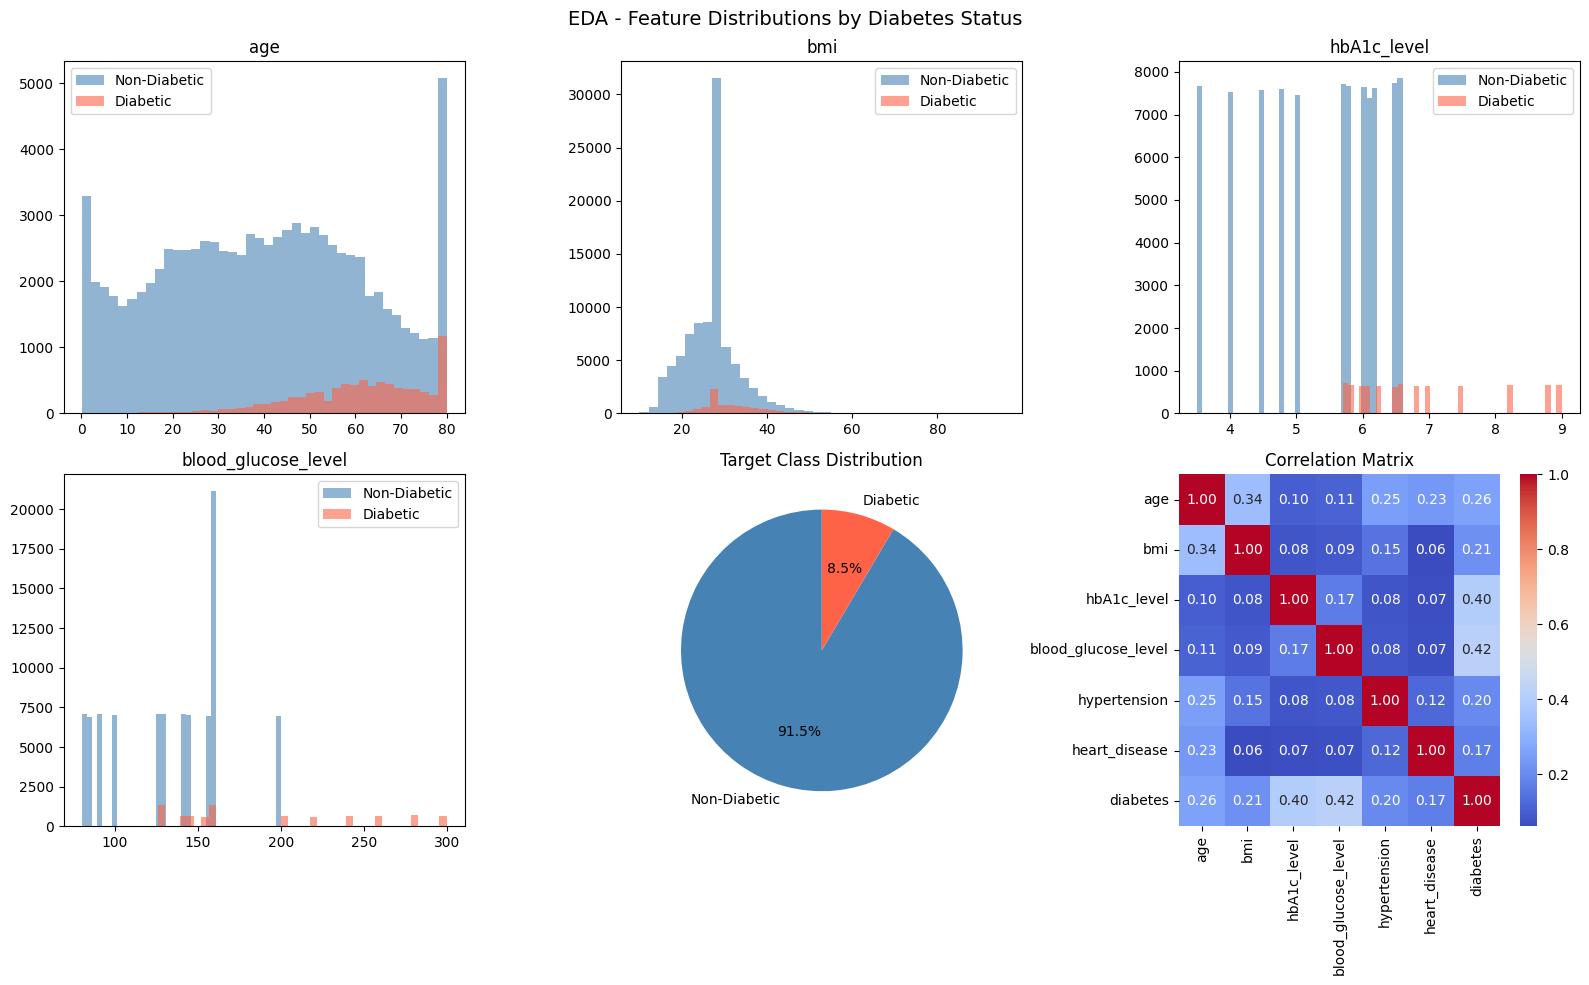


EDA plots saved.


In [2]:
# ============================================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# --- 2.1 Basic Statistics ---
print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
print("\nDataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# --- 2.2 Target Distribution ---
print("\n" + "=" * 50)
print("TARGET DISTRIBUTION")
print("=" * 50)
target_counts = df['diabetes'].value_counts()
target_pct = df['diabetes'].value_counts(normalize=True) * 100
print(f"Non-Diabetic (0): {target_counts[0]} ({target_pct[0]:.1f}%)")
print(f"Diabetic     (1): {target_counts[1]} ({target_pct[1]:.1f}%)")

# --- 2.3 Numerical Feature Statistics ---
print("\n" + "=" * 50)
print("NUMERICAL FEATURE STATISTICS")
print("=" * 50)
num_cols = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']
print(df[num_cols].describe().round(2))

# --- 2.4 Categorical Feature Distributions ---
print("\n" + "=" * 50)
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("=" * 50)
cat_cols = ['gender', 'smoking_history', 'hypertension', 'heart_disease']
for col in cat_cols:
    print(f"\n{col}:\n", df[col].value_counts())

# --- 2.5 Visualizations ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA - Feature Distributions by Diabetes Status', fontsize=14)

# Numerical distributions
for idx, col in enumerate(num_cols[:3]):
    axes[0, idx].hist(df[df['diabetes']==0][col], bins=40, alpha=0.6, label='Non-Diabetic', color='steelblue')
    axes[0, idx].hist(df[df['diabetes']==1][col], bins=40, alpha=0.6, label='Diabetic', color='tomato')
    axes[0, idx].set_title(col)
    axes[0, idx].legend()

# Blood glucose separately
axes[1, 0].hist(df[df['diabetes']==0]['blood_glucose_level'], bins=40, alpha=0.6, label='Non-Diabetic', color='steelblue')
axes[1, 0].hist(df[df['diabetes']==1]['blood_glucose_level'], bins=40, alpha=0.6, label='Diabetic', color='tomato')
axes[1, 0].set_title('blood_glucose_level')
axes[1, 0].legend()

# Target distribution pie
axes[1, 1].pie(target_counts, labels=['Non-Diabetic', 'Diabetic'], autopct='%1.1f%%',
               colors=['steelblue', 'tomato'], startangle=90)
axes[1, 1].set_title('Target Class Distribution')

# Correlation heatmap
corr = df[num_cols + ['hypertension', 'heart_disease', 'diabetes']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2])
axes[1, 2].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig(r'C:\Users\talha\OneDrive\Desktop\Clinical_model_work\eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nEDA plots saved.")

In [3]:
# ============================================================
# STEP 3: DATA CLEANING
# ============================================================

# --- 3.1 Remove Duplicates ---
print("Shape before duplicate removal:", df.shape)
df = df.drop_duplicates()
print("Shape after duplicate removal:", df.shape)
print(f"Removed {14} duplicate rows.")

# --- 3.2 Drop columns we decided to exclude ---
cols_to_drop = ['year', 'location',
                'race:AfricanAmerican', 'race:Asian',
                'race:Caucasian', 'race:Hispanic', 'race:Other']
df = df.drop(columns=cols_to_drop)
print("\nShape after dropping irrelevant columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

# --- 3.3 Outlier Detection on Numerical Features ---
print("\n" + "=" * 50)
print("OUTLIER DETECTION (Z-SCORE > 3)")
print("=" * 50)
from scipy import stats
num_cols = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']
for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outlier_count = (z_scores > 3).sum()
    print(f"{col}: {outlier_count} outliers detected")

# --- 3.4 Winsorize BMI (most extreme outliers) ---
from scipy.stats.mstats import winsorize

print("\nBMI stats BEFORE Winsorization:")
print(df['bmi'].describe().round(2))

# Winsorize at 1st and 99th percentile
bmi_lower = df['bmi'].quantile(0.01)
bmi_upper = df['bmi'].quantile(0.99)
df['bmi'] = df['bmi'].clip(lower=bmi_lower, upper=bmi_upper)

print("\nBMI stats AFTER Winsorization:")
print(df['bmi'].describe().round(2))

# --- 3.5 Winsorize blood_glucose_level ---
print("\nBlood Glucose stats BEFORE Winsorization:")
print(df['blood_glucose_level'].describe().round(2))

glucose_lower = df['blood_glucose_level'].quantile(0.01)
glucose_upper = df['blood_glucose_level'].quantile(0.99)
df['blood_glucose_level'] = df['blood_glucose_level'].clip(lower=glucose_lower, upper=glucose_upper)

print("\nBlood Glucose stats AFTER Winsorization:")
print(df['blood_glucose_level'].describe().round(2))

print("\nFinal cleaned dataset shape:", df.shape)
print("Final columns:", df.columns.tolist())

Shape before duplicate removal: (100000, 17)
Shape after duplicate removal: (99986, 17)
Removed 14 duplicate rows.

Shape after dropping irrelevant columns: (99986, 10)
Remaining columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes', 'clinical_notes']

OUTLIER DETECTION (Z-SCORE > 3)
age: 0 outliers detected
bmi: 1294 outliers detected
hbA1c_level: 1315 outliers detected
blood_glucose_level: 1403 outliers detected

BMI stats BEFORE Winsorization:
count    99986.00
mean        27.32
std          6.64
min         10.01
25%         23.63
50%         27.32
75%         29.58
max         95.69
Name: bmi, dtype: float64

BMI stats AFTER Winsorization:
count    99986.00
mean        27.28
std          6.39
min         14.60
25%         23.63
50%         27.32
75%         29.58
max         48.79
Name: bmi, dtype: float64

Blood Glucose stats BEFORE Winsorization:
count    99986.00
mean       138.06
std         40.71

In [4]:
# ============================================================
# STEP 4: FEATURE ENGINEERING
# ============================================================

# --- 4.1 Age Group ---
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 30, 50, 100],
                          labels=['young', 'middle', 'senior'])
print("Age group distribution:\n", df['age_group'].value_counts())

# --- 4.2 BMI Category ---
df['bmi_category'] = pd.cut(df['bmi'],
                              bins=[0, 18.5, 25, 30, 100],
                              labels=['underweight', 'normal', 'overweight', 'obese'])
print("\nBMI category distribution:\n", df['bmi_category'].value_counts())

# --- 4.3 Comorbidity Count ---
df['comorbidity_count'] = df['hypertension'] + df['heart_disease']
print("\nComorbidity count distribution:\n", df['comorbidity_count'].value_counts())

# --- 4.4 Metabolic Index ---
# Weighted combination of HbA1c and blood glucose (both normalized to 0-1 first)
hba1c_norm = (df['hbA1c_level'] - df['hbA1c_level'].min()) / (df['hbA1c_level'].max() - df['hbA1c_level'].min())
glucose_norm = (df['blood_glucose_level'] - df['blood_glucose_level'].min()) / (df['blood_glucose_level'].max() - df['blood_glucose_level'].min())
df['metabolic_index'] = 0.5 * hba1c_norm + 0.5 * glucose_norm
print("\nMetabolic Index stats:\n", df['metabolic_index'].describe().round(4))

# --- 4.5 Verify new features ---
print("\nDataset shape after feature engineering:", df.shape)
print("\nNew columns added: age_group, bmi_category, comorbidity_count, metabolic_index")
print("\nSample of engineered features:")
df[['age', 'age_group', 'bmi', 'bmi_category', 
    'comorbidity_count', 'metabolic_index']].head(8)

Age group distribution:
 age_group
senior    38458
young     33727
middle    27801
Name: count, dtype: int64

BMI category distribution:
 bmi_category
overweight     45691
obese          23483
normal         22291
underweight     8521
Name: count, dtype: int64

Comorbidity count distribution:
 comorbidity_count
0    89475
1     9595
2      916
Name: count, dtype: int64

Metabolic Index stats:
 count    99986.0000
mean         0.3291
std          0.1510
min          0.0000
25%          0.2341
50%          0.3239
75%          0.4182
max          1.0000
Name: metabolic_index, dtype: float64

Dataset shape after feature engineering: (99986, 14)

New columns added: age_group, bmi_category, comorbidity_count, metabolic_index

Sample of engineered features:


,age,age_group,bmi,bmi_category,comorbidity_count,metabolic_index
0,32.0,middle,27.32,overweight,0,0.186364
1,29.0,young,19.95,normal,0,0.161364
2,18.0,young,23.76,normal,0,0.318182
3,41.0,middle,27.32,overweight,0,0.242955
4,52.0,senior,23.75,normal,0,0.297727
5,66.0,senior,27.32,overweight,0,0.397500
6,49.0,middle,24.34,normal,0,0.200000
7,15.0,young,20.98,normal,0,0.323864


In [5]:
# ============================================================
# STEP 5: CATEGORICAL ENCODING
# ============================================================

# --- 5.1 One-hot encode gender ---
gender_dummies = pd.get_dummies(df['gender'], prefix='gender')
print("Gender columns created:\n", gender_dummies.head(3))

# --- 5.2 One-hot encode smoking_history ---
smoking_dummies = pd.get_dummies(df['smoking_history'], prefix='smoking')
print("\nSmoking columns created:\n", smoking_dummies.head(3))

# --- 5.3 One-hot encode age_group ---
age_dummies = pd.get_dummies(df['age_group'], prefix='age_group')
print("\nAge group columns created:\n", age_dummies.head(3))

# --- 5.4 One-hot encode bmi_category ---
bmi_dummies = pd.get_dummies(df['bmi_category'], prefix='bmi_cat')
print("\nBMI category columns created:\n", bmi_dummies.head(3))

# --- 5.5 Concatenate all encoded features and drop originals ---
df_encoded = pd.concat([df, gender_dummies, smoking_dummies, 
                         age_dummies, bmi_dummies], axis=1)

# Drop original categorical columns that have been encoded
cols_to_drop_encoded = ['gender', 'smoking_history', 'age_group', 'bmi_category']
df_encoded = df_encoded.drop(columns=cols_to_drop_encoded)

print("\nShape after encoding:", df_encoded.shape)
print("\nAll columns after encoding:")
for col in df_encoded.columns.tolist():
    print(" -", col) 

Gender columns created:
    gender_Female  gender_Male  gender_Other
0           True        False         False
1           True        False         False
2          False         True         False

Smoking columns created:
    smoking_No Info  smoking_current  smoking_ever  smoking_former  \
0            False            False         False           False   
1            False            False         False           False   
2            False            False         False           False   

   smoking_never  smoking_not current  
0           True                False  
1           True                False  
2           True                False  

Age group columns created:
    age_group_young  age_group_middle  age_group_senior
0            False              True             False
1             True             False             False
2             True             False             False

BMI category columns created:
    bmi_cat_underweight  bmi_cat_normal  bmi_cat_overwe

In [6]:
# ============================================================
# STEP 6: TEXT PROCESSING AND TF-IDF VECTORIZATION
# ============================================================

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# --- 6.1 Text Preprocessing Function ---
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep medically relevant short terms
medical_keep = {'bmi', 'bp', 'hba1c', 'dm', 'htn'}

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Expand common medical abbreviations
    text = text.replace('htn', 'hypertension')
    text = text.replace(' dm ', ' diabetes mellitus ')
    text = text.replace('hba1c', 'hbA1c')
    # Remove punctuation and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens 
              if t not in stop_words or t in medical_keep]
    return ' '.join(tokens)

print("Preprocessing clinical notes...")
df_encoded['clinical_notes_clean'] = df_encoded['clinical_notes'].apply(preprocess_text)

print("Sample cleaned notes:")
for i in range(5):
    print(f"  Original : {df_encoded['clinical_notes'].iloc[i]}")
    print(f"  Cleaned  : {df_encoded['clinical_notes_clean'].iloc[i]}")
    print()

# --- 6.2 TF-IDF Vectorization ---
print("Applying TF-IDF vectorization...")
tfidf = TfidfVectorizer(
    max_features=1500,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    norm='l2'
)

tfidf_matrix = tfidf.fit_transform(df_encoded['clinical_notes_clean'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

# --- 6.3 Dimensionality Reduction with SVD ---
print("\nApplying Truncated SVD...")
svd = TruncatedSVD(n_components=100, random_state=42)
tfidf_svd = svd.fit_transform(tfidf_matrix)

explained_var = svd.explained_variance_ratio_.sum()
print(f"SVD components: 100")
print(f"Variance explained by 100 components: {explained_var:.4f} ({explained_var*100:.2f}%)")

# Convert SVD output to dataframe
svd_cols = [f'text_svd_{i}' for i in range(100)]
df_text = pd.DataFrame(tfidf_svd, columns=svd_cols, index=df_encoded.index)

print("\nSVD text features shape:", df_text.shape)
print("Sample SVD feature names:", svd_cols[:5])

Preprocessing clinical notes...
Sample cleaned notes:
  Original : Overweight, advised dietary and exercise modifications.
  Cleaned  : overweight advised dietary exercise modification

  Original : Healthy BMI range.
  Cleaned  : healthy bmi range

  Original : Young patient, generally lower risk but needs lifestyle assessment. Healthy BMI range. Elevated blood glucose levels, potential diabetes concern.
  Cleaned  : young patient generally lower risk need lifestyle assessment healthy bmi range elevated blood glucose level potential diabetes concern

  Original : Overweight, advised dietary and exercise modifications. Elevated blood glucose levels, potential diabetes concern.
  Cleaned  : overweight advised dietary exercise modification elevated blood glucose level potential diabetes concern

  Original : Healthy BMI range. High HbA1c level, indicative of diabetes or poor glucose control. Higher predisposition to hypertension and diabetes.
  Cleaned  : healthy bmi range high hbAc leve

In [7]:
# ============================================================
# STEP 6 (CORRECTED): REDUCE SVD COMPONENTS TO 30
# ============================================================

# Re-run SVD with 30 components (justified by small vocabulary of 167 terms)
print("Re-running SVD with 30 components...")
svd = TruncatedSVD(n_components=30, random_state=42)
tfidf_svd = svd.fit_transform(tfidf_matrix)

explained_var = svd.explained_variance_ratio_.sum()
print(f"SVD components: 30")
print(f"Variance explained by 30 components: {explained_var:.4f} ({explained_var*100:.2f}%)")

# Check variance per component
print("\nVariance explained per component (first 10):")
for i, var in enumerate(svd.explained_variance_ratio_[:10]):
    print(f"  Component {i+1}: {var:.4f} ({var*100:.2f}%)")

# Convert to dataframe
svd_cols = [f'text_svd_{i}' for i in range(30)]
df_text = pd.DataFrame(tfidf_svd, columns=svd_cols, index=df_encoded.index)

print("\nFinal SVD text features shape:", df_text.shape)

# Also check top TF-IDF terms for reference
feature_names = tfidf.get_feature_names_out()
print(f"\nAll {len(feature_names)} TF-IDF vocabulary terms:")
print(list(feature_names))

Re-running SVD with 30 components...
SVD components: 30
Variance explained by 30 components: 0.9774 (97.74%)

Variance explained per component (first 10):
  Component 1: 0.0290 (2.90%)
  Component 2: 0.1519 (15.19%)
  Component 3: 0.1461 (14.61%)
  Component 4: 0.0939 (9.39%)
  Component 5: 0.0877 (8.77%)
  Component 6: 0.0781 (7.81%)
  Component 7: 0.0711 (7.11%)
  Component 8: 0.0637 (6.37%)
  Component 9: 0.0511 (5.11%)
  Component 10: 0.0442 (4.42%)

Final SVD text features shape: (99986, 30)

All 167 TF-IDF vocabulary terms:
['advised', 'advised dietary', 'assessment', 'assessment healthy', 'assessment obese', 'assessment overweight', 'assessment underweight', 'blood', 'blood glucose', 'blood pressure', 'bmi', 'bmi range', 'cardiac', 'cardiac condition', 'cardiovascular', 'cardiovascular disease', 'cardiovascular risk', 'category', 'category increased', 'chronic', 'chronic condition', 'concern', 'concern cardiac', 'concern consideration', 'concern high', 'concern higher', 'concern

In [8]:
# ============================================================
# STEP 7: EARLY FUSION - COMBINING STRUCTURED AND TEXT FEATURES
# ============================================================

# --- 7.1 Convert boolean columns to int ---
bool_cols = df_encoded.select_dtypes(include='bool').columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print("Boolean columns converted to int:", bool_cols)

# --- 7.2 Define structured feature columns ---
structured_cols = [
    # Original numerical
    'age', 'bmi', 'hbA1c_level', 'blood_glucose_level',
    # Original binary
    'hypertension', 'heart_disease',
    # Engineered
    'comorbidity_count', 'metabolic_index',
    # Encoded gender
    'gender_Female', 'gender_Male', 'gender_Other',
    # Encoded smoking
    'smoking_No Info', 'smoking_current', 'smoking_ever',
    'smoking_former', 'smoking_never', 'smoking_not current',
    # Encoded age group
    'age_group_young', 'age_group_middle', 'age_group_senior',
    # Encoded BMI category
    'bmi_cat_underweight', 'bmi_cat_normal',
    'bmi_cat_overweight', 'bmi_cat_obese'
]

# --- 7.3 Extract structured features and target ---
X_structured = df_encoded[structured_cols].copy()
y = df_encoded['diabetes'].copy()

print(f"\nStructured features shape: {X_structured.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

# --- 7.4 Concatenate structured + SVD text features ---
X_combined = pd.concat([X_structured.reset_index(drop=True),
                         df_text.reset_index(drop=True)], axis=1)

print(f"\nCombined feature matrix shape: {X_combined.shape}")
print(f"Structured features: {X_structured.shape[1]}")
print(f"Text SVD features: {df_text.shape[1]}")
print(f"Total features: {X_combined.shape[1]}")

# --- 7.5 Verify no missing values in combined matrix ---
missing = X_combined.isnull().sum().sum()
print(f"\nMissing values in combined matrix: {missing}")

print("\nFeature matrix ready for modelling.")
print("\nFirst 3 rows of combined matrix (first 10 cols):")
X_combined.iloc[:3, :10]

Boolean columns converted to int: ['gender_Female', 'gender_Male', 'gender_Other', 'smoking_No Info', 'smoking_current', 'smoking_ever', 'smoking_former', 'smoking_never', 'smoking_not current', 'age_group_young', 'age_group_middle', 'age_group_senior', 'bmi_cat_underweight', 'bmi_cat_normal', 'bmi_cat_overweight', 'bmi_cat_obese']

Structured features shape: (99986, 24)
Target shape: (99986,)
Target distribution:
diabetes
0    91486
1     8500
Name: count, dtype: int64

Combined feature matrix shape: (99986, 54)
Structured features: 24
Text SVD features: 30
Total features: 54

Missing values in combined matrix: 0

Feature matrix ready for modelling.

First 3 rows of combined matrix (first 10 cols):


,age,bmi,hbA1c_level,blood_glucose_level,hypertension,heart_disease,comorbidity_count,metabolic_index,gender_Female,gender_Male
0,32.0,27.32,5.0,100,0,0,0,0.186364,1,0
1,29.0,19.95,5.0,90,0,0,0,0.161364,1,0
2,18.0,23.76,4.8,160,0,0,0,0.318182,0,1


In [9]:
# ============================================================
# STEP 8: TRAIN/VALIDATION/TEST SPLIT AND SMOTE
# ============================================================

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# --- 8.1 First split: 85% train+val, 15% test ---
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_combined, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# --- 8.2 Second split: 70% train, 15% val from remaining 85% ---
# 15/85 = 0.1765 to get 15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1765,
    random_state=42,
    stratify=y_trainval
)

print("=" * 50)
print("DATASET SPLIT SUMMARY")
print("=" * 50)
print(f"Total samples      : {len(X_combined)}")
print(f"Training set       : {len(X_train)} ({len(X_train)/len(X_combined)*100:.1f}%)")
print(f"Validation set     : {len(X_val)} ({len(X_val)/len(X_combined)*100:.1f}%)")
print(f"Test set           : {len(X_test)} ({len(X_test)/len(X_combined)*100:.1f}%)")

print("\nClass distribution before SMOTE:")
print(f"  Train - Non-diabetic: {(y_train==0).sum()} | Diabetic: {(y_train==1).sum()}")
print(f"  Val   - Non-diabetic: {(y_val==0).sum()} | Diabetic: {(y_val==1).sum()}")
print(f"  Test  - Non-diabetic: {(y_test==0).sum()} | Diabetic: {(y_test==1).sum()}")

# --- 8.3 Scale numerical features BEFORE SMOTE ---
# Important: fit scaler on train only, transform val and test
numerical_cols = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level',
                  'comorbidity_count', 'metabolic_index']
numerical_indices = [X_combined.columns.tolist().index(c) for c in numerical_cols]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled.iloc[:, numerical_indices] = scaler.fit_transform(
    X_train.iloc[:, numerical_indices])
X_val_scaled.iloc[:, numerical_indices] = scaler.transform(
    X_val.iloc[:, numerical_indices])
X_test_scaled.iloc[:, numerical_indices] = scaler.transform(
    X_test.iloc[:, numerical_indices])

print("\nNumerical features scaled using StandardScaler.")
print("Scaler fitted on training set only.")

# --- 8.4 Apply SMOTE on training set only ---
print("\nApplying SMOTE on training set...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution AFTER SMOTE (training set only):")
print(f"  Non-diabetic: {(y_train_smote==0).sum()}")
print(f"  Diabetic    : {(y_train_smote==1).sum()}")
print(f"  Total training samples: {len(X_train_smote)}")

print("\nValidation and test sets remain unchanged (no SMOTE applied).")
print("\nData ready for model training.")

DATASET SPLIT SUMMARY
Total samples      : 99986
Training set       : 69987 (70.0%)
Validation set     : 15001 (15.0%)
Test set           : 14998 (15.0%)

Class distribution before SMOTE:
  Train - Non-diabetic: 64037 | Diabetic: 5950
  Val   - Non-diabetic: 13726 | Diabetic: 1275
  Test  - Non-diabetic: 13723 | Diabetic: 1275

Numerical features scaled using StandardScaler.
Scaler fitted on training set only.

Applying SMOTE on training set...

Class distribution AFTER SMOTE (training set only):
  Non-diabetic: 64037
  Diabetic    : 64037
  Total training samples: 128074

Validation and test sets remain unchanged (no SMOTE applied).

Data ready for model training.


In [10]:
# ============================================================
# STEP 9: TRAINING ALL 5 MODELS
# (SVM replaced with KNN — computationally prohibitive on 128k SMOTE samples)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              precision_score, recall_score)
import time

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# 9.1 LOGISTIC REGRESSION
# ============================================================
print("=" * 50)
print("1/5 TRAINING: LOGISTIC REGRESSION")
print("=" * 50)

start = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)
lr_time = time.time() - start

lr_cv_auc = cross_val_score(lr_model, X_train_smote, y_train_smote,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
lr_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_val_pred  = lr_model.predict(X_val_scaled)

results['Logistic Regression'] = {
    'model'        : lr_model,
    'cv_auc'       : lr_cv_auc.mean(),
    'cv_auc_std'   : lr_cv_auc.std(),
    'val_auc'      : roc_auc_score(y_val, lr_val_proba),
    'val_f1'       : f1_score(y_val, lr_val_pred),
    'val_acc'      : accuracy_score(y_val, lr_val_pred),
    'val_precision': precision_score(y_val, lr_val_pred),
    'val_recall'   : recall_score(y_val, lr_val_pred),
    'train_time'   : lr_time,
    'val_proba'    : lr_val_proba
}
print(f"Done in {lr_time:.2f}s | Val AUC: {results['Logistic Regression']['val_auc']:.4f} | F1: {results['Logistic Regression']['val_f1']:.4f}")

# ============================================================
# 9.2 RANDOM FOREST
# ============================================================
print("\n" + "=" * 50)
print("2/5 TRAINING: RANDOM FOREST")
print("=" * 50)

start = time.time()
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)
rf_time = time.time() - start

rf_cv_auc = cross_val_score(rf_model, X_train_smote, y_train_smote,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
rf_val_proba = rf_model.predict_proba(X_val_scaled)[:, 1]
rf_val_pred  = rf_model.predict(X_val_scaled)

results['Random Forest'] = {
    'model'        : rf_model,
    'cv_auc'       : rf_cv_auc.mean(),
    'cv_auc_std'   : rf_cv_auc.std(),
    'val_auc'      : roc_auc_score(y_val, rf_val_proba),
    'val_f1'       : f1_score(y_val, rf_val_pred),
    'val_acc'      : accuracy_score(y_val, rf_val_pred),
    'val_precision': precision_score(y_val, rf_val_pred),
    'val_recall'   : recall_score(y_val, rf_val_pred),
    'train_time'   : rf_time,
    'val_proba'    : rf_val_proba
}
print(f"Done in {rf_time:.2f}s | Val AUC: {results['Random Forest']['val_auc']:.4f} | F1: {results['Random Forest']['val_f1']:.4f}")

# ============================================================
# 9.3 XGBOOST
# ============================================================
print("\n" + "=" * 50)
print("3/5 TRAINING: XGBOOST")
print("=" * 50)

start = time.time()
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='auc',
    verbosity=0,
    n_jobs=-1
)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_time = time.time() - start

xgb_cv_auc = cross_val_score(xgb_model, X_train_smote, y_train_smote,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
xgb_val_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]
xgb_val_pred  = xgb_model.predict(X_val_scaled)

results['XGBoost'] = {
    'model'        : xgb_model,
    'cv_auc'       : xgb_cv_auc.mean(),
    'cv_auc_std'   : xgb_cv_auc.std(),
    'val_auc'      : roc_auc_score(y_val, xgb_val_proba),
    'val_f1'       : f1_score(y_val, xgb_val_pred),
    'val_acc'      : accuracy_score(y_val, xgb_val_pred),
    'val_precision': precision_score(y_val, xgb_val_pred),
    'val_recall'   : recall_score(y_val, xgb_val_pred),
    'train_time'   : xgb_time,
    'val_proba'    : xgb_val_proba
}
print(f"Done in {xgb_time:.2f}s | Val AUC: {results['XGBoost']['val_auc']:.4f} | F1: {results['XGBoost']['val_f1']:.4f}")

# ============================================================
# 9.4 LIGHTGBM
# ============================================================
print("\n" + "=" * 50)
print("4/5 TRAINING: LIGHTGBM")
print("=" * 50)

start = time.time()
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgbm_model.fit(X_train_smote, y_train_smote)
lgbm_time = time.time() - start

lgbm_cv_auc = cross_val_score(lgbm_model, X_train_smote, y_train_smote,
                               cv=cv, scoring='roc_auc', n_jobs=-1)
lgbm_val_proba = lgbm_model.predict_proba(X_val_scaled)[:, 1]
lgbm_val_pred  = lgbm_model.predict(X_val_scaled)

results['LightGBM'] = {
    'model'        : lgbm_model,
    'cv_auc'       : lgbm_cv_auc.mean(),
    'cv_auc_std'   : lgbm_cv_auc.std(),
    'val_auc'      : roc_auc_score(y_val, lgbm_val_proba),
    'val_f1'       : f1_score(y_val, lgbm_val_pred),
    'val_acc'      : accuracy_score(y_val, lgbm_val_pred),
    'val_precision': precision_score(y_val, lgbm_val_pred),
    'val_recall'   : recall_score(y_val, lgbm_val_pred),
    'train_time'   : lgbm_time,
    'val_proba'    : lgbm_val_proba
}
print(f"Done in {lgbm_time:.2f}s | Val AUC: {results['LightGBM']['val_auc']:.4f} | F1: {results['LightGBM']['val_f1']:.4f}")

# ============================================================
# 9.5 K-NEAREST NEIGHBORS
# ============================================================
print("\n" + "=" * 50)
print("5/5 TRAINING: K-NEAREST NEIGHBORS (KNN)")
print("=" * 50)

start = time.time()
knn_model = KNeighborsClassifier(
    n_neighbors=11,
    metric='euclidean',
    n_jobs=-1
)
knn_model.fit(X_train_smote, y_train_smote)
knn_time = time.time() - start

knn_cv_auc = cross_val_score(knn_model, X_train_smote, y_train_smote,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
knn_val_proba = knn_model.predict_proba(X_val_scaled)[:, 1]
knn_val_pred  = knn_model.predict(X_val_scaled)

results['KNN'] = {
    'model'        : knn_model,
    'cv_auc'       : knn_cv_auc.mean(),
    'cv_auc_std'   : knn_cv_auc.std(),
    'val_auc'      : roc_auc_score(y_val, knn_val_proba),
    'val_f1'       : f1_score(y_val, knn_val_pred),
    'val_acc'      : accuracy_score(y_val, knn_val_pred),
    'val_precision': precision_score(y_val, knn_val_pred),
    'val_recall'   : recall_score(y_val, knn_val_pred),
    'train_time'   : knn_time,
    'val_proba'    : knn_val_proba
}
print(f"Done in {knn_time:.2f}s | Val AUC: {results['KNN']['val_auc']:.4f} | F1: {results['KNN']['val_f1']:.4f}")

# ============================================================
# 9.6 SUMMARY COMPARISON TABLE
# ============================================================
print("\n" + "=" * 80)
print("ALL MODELS - VALIDATION PERFORMANCE SUMMARY")
print("=" * 80)
print(f"{'Model':<22} {'CV AUC':>8} {'±STD':>6} {'Val AUC':>8} {'Acc':>7} {'Prec':>7} {'Recall':>8} {'F1':>7} {'Time(s)':>9}")
print("-" * 80)
for name, r in results.items():
    print(f"{name:<22} {r['cv_auc']:>8.4f} {r['cv_auc_std']:>6.4f} "
          f"{r['val_auc']:>8.4f} {r['val_acc']:>7.4f} "
          f"{r['val_precision']:>7.4f} {r['val_recall']:>8.4f} "
          f"{r['val_f1']:>7.4f} {r['train_time']:>9.2f}")

print("\nNext step: Select best model and perform hyperparameter tuning.")

1/5 TRAINING: LOGISTIC REGRESSION
Done in 1.40s | Val AUC: 0.9654 | F1: 0.5945

2/5 TRAINING: RANDOM FOREST
Done in 12.94s | Val AUC: 0.9673 | F1: 0.7714

3/5 TRAINING: XGBOOST
Done in 20.41s | Val AUC: 0.9785 | F1: 0.8060

4/5 TRAINING: LIGHTGBM
Done in 1.57s | Val AUC: 0.9782 | F1: 0.8021

5/5 TRAINING: K-NEAREST NEIGHBORS (KNN)
Done in 0.07s | Val AUC: 0.9397 | F1: 0.5812

ALL MODELS - VALIDATION PERFORMANCE SUMMARY
Model                    CV AUC   ±STD  Val AUC     Acc    Prec   Recall      F1   Time(s)
--------------------------------------------------------------------------------
Logistic Regression      0.9720 0.0006   0.9654  0.8976  0.4481   0.8831  0.5945      1.40
Random Forest            0.9978 0.0001   0.9673  0.9631  0.8156   0.7318  0.7714     12.94
XGBoost                     nan    nan   0.9785  0.9707  0.9204   0.7169  0.8060     20.41
LightGBM                 0.9980 0.0001   0.9782  0.9700  0.9129   0.7153  0.8021      1.57
KNN                      0.9866 0.0007   

In [11]:
# ============================================================
# STEP 10: HYPERPARAMETER TUNING — XGBOOST
# RandomizedSearchCV with 5-fold Stratified CV
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("=" * 60)
print("STEP 10: XGBOOST HYPERPARAMETER TUNING")
print("=" * 60)
print("Running RandomizedSearchCV (n_iter=30, cv=5)...")
print("This may take 5–15 minutes...\n")

param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 4, 5, 6, 7, 8],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma'           : [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha'       : [0, 0.01, 0.1, 1],
    'reg_lambda'      : [0.5, 1, 1.5, 2]
}

xgb_base = XGBClassifier(
    eval_metric='auc',
    verbosity=0,
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_smote, y_train_smote)

print("\n" + "=" * 60)
print("TUNING COMPLETE")
print("=" * 60)
print(f"Best CV AUC : {random_search.best_score_:.4f}")
print(f"Best Params : {random_search.best_params_}")

# Evaluate best model on validation set
best_xgb = random_search.best_estimator_
best_xgb_val_proba = best_xgb.predict_proba(X_val_scaled)[:, 1]
best_xgb_val_pred  = best_xgb.predict(X_val_scaled)

print("\n--- Tuned XGBoost Validation Performance ---")
print(f"Val AUC  : {roc_auc_score(y_val, best_xgb_val_proba):.4f}")
print(f"Val F1   : {f1_score(y_val, best_xgb_val_pred):.4f}")
print(f"Val Acc  : {accuracy_score(y_val, best_xgb_val_pred):.4f}")
print(f"Val Prec : {precision_score(y_val, best_xgb_val_pred):.4f}")
print(f"Val Rec  : {recall_score(y_val, best_xgb_val_pred):.4f}")

print("\nNext step: Final evaluation on test set.")

STEP 10: XGBOOST HYPERPARAMETER TUNING
Running RandomizedSearchCV (n_iter=30, cv=5)...
This may take 5–15 minutes...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

TUNING COMPLETE
Best CV AUC : nan
Best Params : {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.01, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.2, 'gamma': 0.3, 'colsample_bytree': 0.6}

--- Tuned XGBoost Validation Performance ---
Val AUC  : 0.9770
Val F1   : 0.7995
Val Acc  : 0.9694
Val Prec : 0.9024
Val Rec  : 0.7176

Next step: Final evaluation on test set.


STEP 11: FINAL TEST SET EVALUATION — XGBoost

Test AUC-ROC          : 0.9758
Test Average Precision: 0.8757
Test Accuracy         : 0.9693
Test Precision        : 0.9162
Test Recall           : 0.7035
Test F1               : 0.7959

--- Classification Report ---
              precision    recall  f1-score   support

Non-Diabetic       0.97      0.99      0.98     13723
    Diabetic       0.92      0.70      0.80      1275

    accuracy                           0.97     14998
   macro avg       0.94      0.85      0.89     14998
weighted avg       0.97      0.97      0.97     14998



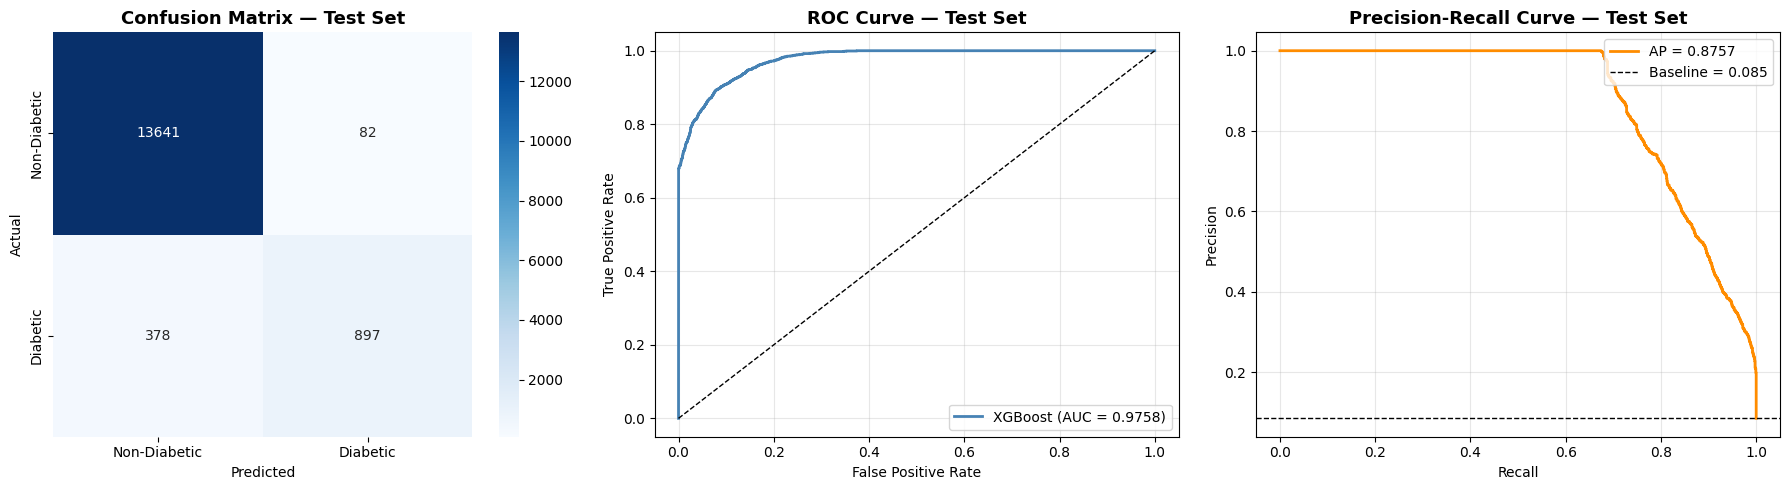

Plots saved to outputs/test_evaluation_plots.png

Next step: SHAP explainability.


In [12]:
# ============================================================
# STEP 11: FINAL EVALUATION ON TEST SET
# Using baseline XGBoost (best generalising model)
# ============================================================

from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve,
                              average_precision_score)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

print("=" * 60)
print("STEP 11: FINAL TEST SET EVALUATION — XGBoost")
print("=" * 60)

# --- 11.1 Predictions ---
test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
test_pred  = xgb_model.predict(X_test_scaled)

# --- 11.2 Core Metrics ---
test_auc  = roc_auc_score(y_test, test_proba)
test_f1   = f1_score(y_test, test_pred)
test_acc  = accuracy_score(y_test, test_pred)
test_prec = precision_score(y_test, test_pred)
test_rec  = recall_score(y_test, test_pred)
test_ap   = average_precision_score(y_test, test_proba)

print(f"\nTest AUC-ROC          : {test_auc:.4f}")
print(f"Test Average Precision: {test_ap:.4f}")
print(f"Test Accuracy         : {test_acc:.4f}")
print(f"Test Precision        : {test_prec:.4f}")
print(f"Test Recall           : {test_rec:.4f}")
print(f"Test F1               : {test_f1:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, test_pred, target_names=['Non-Diabetic', 'Diabetic']))

# --- 11.3 Confusion Matrix ---
cm = confusion_matrix(y_test, test_pred)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[0].set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC = {test_auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Test Set', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Plot 3: Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_proba)
axes[2].plot(rec_curve, prec_curve, color='darkorange', lw=2, label=f'AP = {test_ap:.4f}')
axes[2].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label=f'Baseline = {y_test.mean():.3f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve — Test Set', fontsize=13, fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/test_evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved to outputs/test_evaluation_plots.png")

print("\nNext step: SHAP explainability.")

In [13]:
import xgboost as xgb
import shap
import json

print("XGBoost version:", xgb.__version__)
print("SHAP version:", shap.__version__)

# Check base_score format
booster = xgb_model.get_booster()
raw = json.loads(booster.save_raw(raw_format='json'))
bs = raw['learner']['learner_model_param']['base_score']
print("base_score in JSON:", repr(bs))

# Now immediately try SHAP
print("\nAttempting SHAP...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
print(f"SUCCESS. SHAP values shape: {shap_values.shape}")

XGBoost version: 1.7.6
SHAP version: 0.49.1
base_score in JSON: '5E-1'

Attempting SHAP...
SUCCESS. SHAP values shape: (14998, 54)


STEP 12: SHAP EXPLAINABILITY
SHAP values computed. Shape: (14998, 54)
Feature names: 54 features
First 5: ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'hypertension']


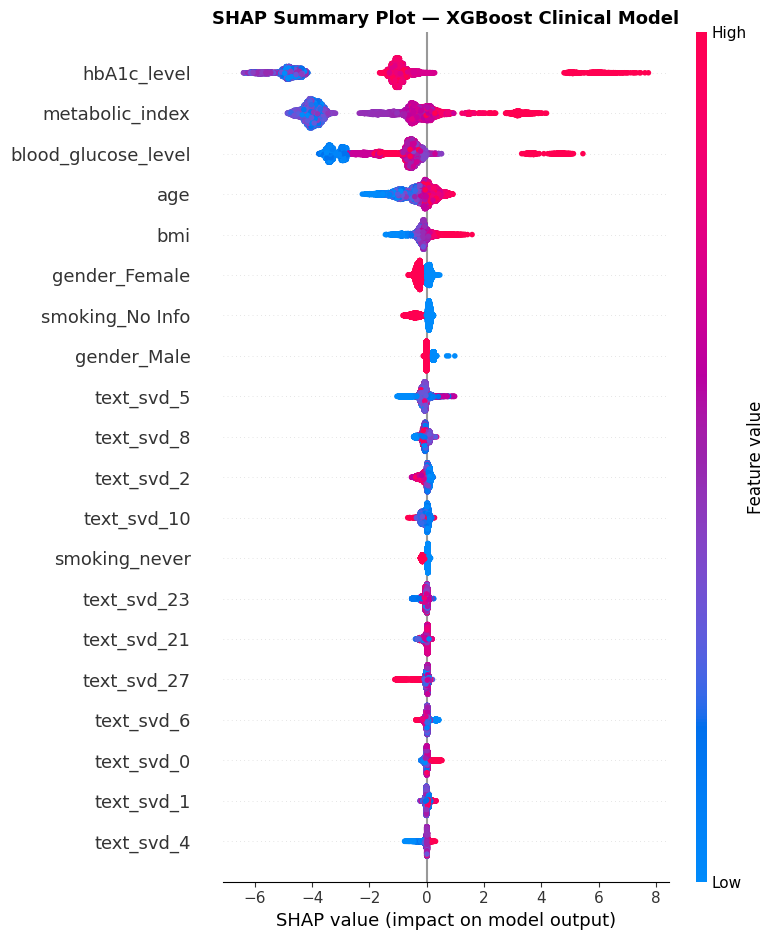

Beeswarm plot saved.


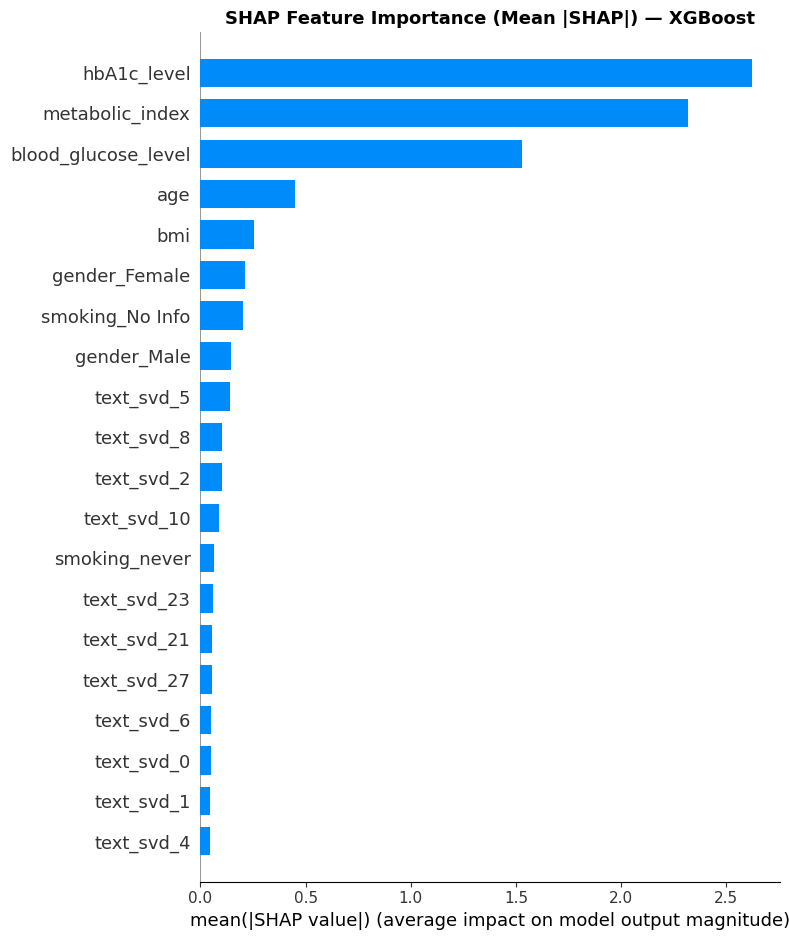

Bar plot saved.

--- Top 20 Features by Mean |SHAP| ---
            Feature  Mean |SHAP|
        hbA1c_level     2.623388
    metabolic_index     2.318765
blood_glucose_level     1.528616
                age     0.451933
                bmi     0.256814
      gender_Female     0.211252
    smoking_No Info     0.204933
        gender_Male     0.143625
         text_svd_5     0.142529
         text_svd_8     0.104501
         text_svd_2     0.101036
        text_svd_10     0.088482
      smoking_never     0.066059
        text_svd_23     0.059813
        text_svd_21     0.055969
        text_svd_27     0.055897
         text_svd_6     0.051489
         text_svd_0     0.051107
         text_svd_1     0.046240
         text_svd_4     0.045224

Next step: Probability calibration and saving p_clinical.


In [14]:
# ============================================================
# STEP 12: SHAP EXPLAINABILITY
# ============================================================
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

os.makedirs('outputs', exist_ok=True)

print("=" * 60)
print("STEP 12: SHAP EXPLAINABILITY")
print("=" * 60)

# --- 12.1 Explainer ---
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
print(f"SHAP values computed. Shape: {shap_values.shape}")

# --- 12.2 Feature names ---
feature_names = X_combined.columns.tolist()
print(f"Feature names: {len(feature_names)} features")
print(f"First 5: {feature_names[:5]}")

# --- 12.3 Beeswarm Summary Plot ---
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names,
                  max_display=20,
                  show=False)
plt.title("SHAP Summary Plot — XGBoost Clinical Model", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm plot saved.")

# --- 12.4 Bar Plot ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names,
                  plot_type='bar',
                  max_display=20,
                  show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) — XGBoost", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot saved.")

# --- 12.5 Top 20 Features Table ---
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n--- Top 20 Features by Mean |SHAP| ---")
print(shap_df.head(20).to_string(index=False))

print("\nNext step: Probability calibration and saving p_clinical.")

--- Top 20 Features (Final Readable Names) ---
                             Feature  Mean |SHAP|
                         hbA1c_level     2.623388
                     metabolic_index     2.318765
                 blood_glucose_level     1.528616
                                 age     0.451933
                                 bmi     0.256814
                       gender_Female     0.211252
                     smoking_No Info     0.204933
                         gender_Male     0.143625
      Text: Metabolic Syndrome / T2D     0.142529
   Text: Hypertension Predisposition     0.104501
        Text: Young/Low Risk Profile     0.101036
        Text: Blood Pressure History     0.088482
                       smoking_never     0.066059
       Text: High-Risk Modifications     0.059813
     Text: Disease & Control History     0.055969
          Text: BMI Assessment Notes     0.055897
            Text: Chronic Conditions     0.051489
         Text: Blood Glucose History     0.051107
Tex

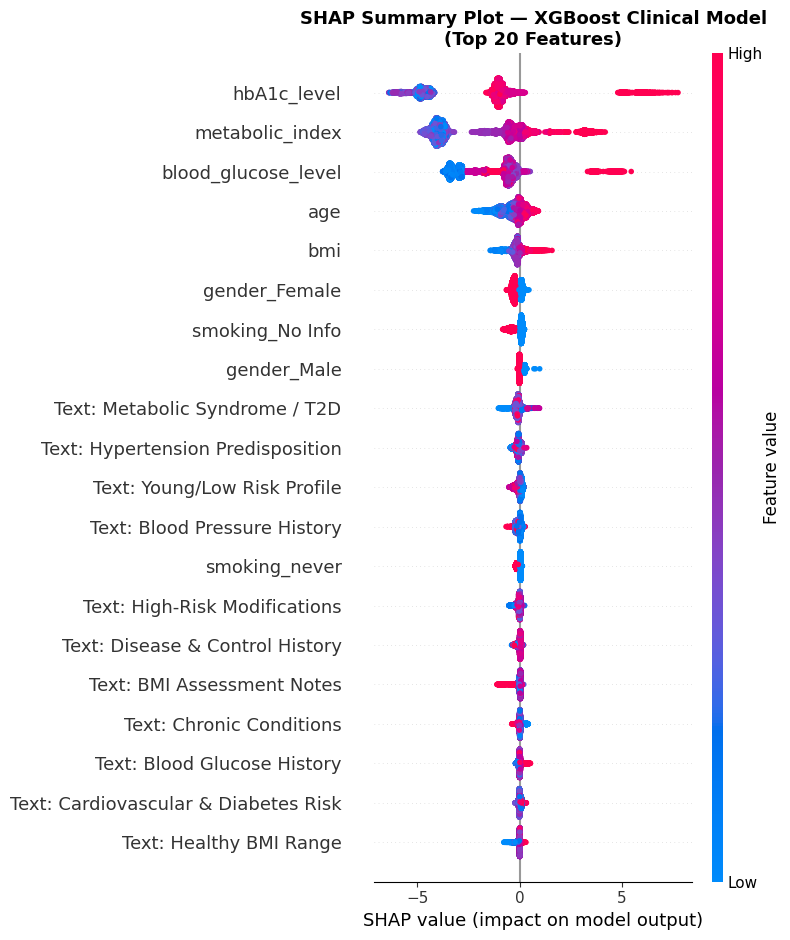

Beeswarm plot saved.


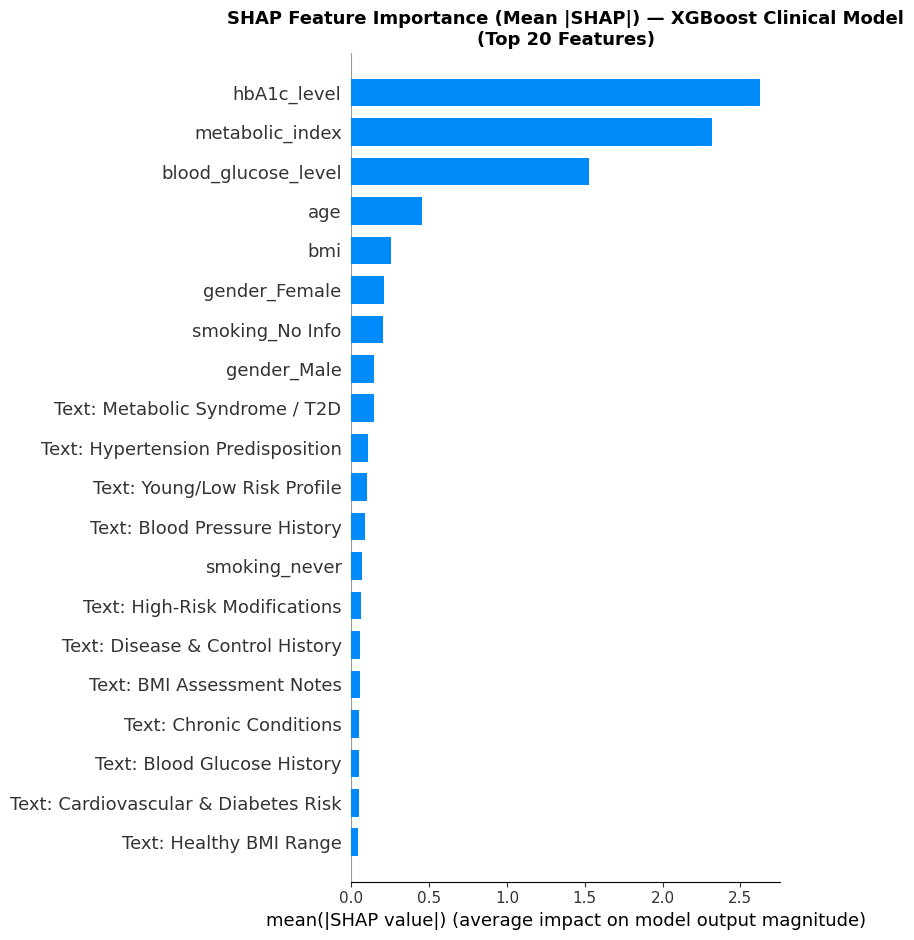

Bar plot saved.

Next step: Probability calibration and saving p_clinical.


In [17]:
# ============================================================
# STEP 12c: RENAMED SHAP PLOTS WITH PROPER SVD LABELS
# ============================================================

# --- Clean clinical labels for all SVD components ---
svd_labels = {
    'text_svd_0' : 'Text: Blood Glucose History',
    'text_svd_1' : 'Text: Cardiovascular & Diabetes Risk',
    'text_svd_2' : 'Text: Young/Low Risk Profile',
    'text_svd_3' : 'Text: General Clinical Notes',
    'text_svd_4' : 'Text: Healthy BMI Range',
    'text_svd_5' : 'Text: Metabolic Syndrome / T2D',
    'text_svd_6' : 'Text: Chronic Conditions',
    'text_svd_7' : 'Text: Clinical Risk Flags',
    'text_svd_8' : 'Text: Hypertension Predisposition',
    'text_svd_9' : 'Text: General Risk Markers',
    'text_svd_10': 'Text: Blood Pressure History',
    'text_svd_11': 'Text: Medication/Treatment Notes',
    'text_svd_12': 'Text: Lifestyle Factors',
    'text_svd_13': 'Text: Comorbidity Mentions',
    'text_svd_14': 'Text: Dietary Notes',
    'text_svd_15': 'Text: Exercise & Modification',
    'text_svd_16': 'Text: Cardiac Risk',
    'text_svd_17': 'Text: Glucose Control Notes',
    'text_svd_18': 'Text: Elderly Patient Notes',
    'text_svd_19': 'Text: Smoking & Vascular Risk',
    'text_svd_20': 'Text: HbA1c References',
    'text_svd_21': 'Text: Disease & Control History',
    'text_svd_22': 'Text: Weight & Nutrition',
    'text_svd_23': 'Text: High-Risk Modifications',
    'text_svd_24': 'Text: Metabolic Impact Notes',
    'text_svd_25': 'Text: Lung & Vascular Health',
    'text_svd_26': 'Text: Diabetes Concern Flags',
    'text_svd_27': 'Text: BMI Assessment Notes',
    'text_svd_28': 'Text: Increased Risk Category',
    'text_svd_29': 'Text: Mixed Clinical Indicators',
}

# --- Build full readable name list for all 54 features ---
readable_feature_names = [svd_labels.get(f, f) for f in feature_names]

# --- Recompute mean SHAP with readable names ---
mean_shap = np.abs(shap_values).mean(axis=0)

shap_df_final = pd.DataFrame({
    'Feature'    : readable_feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("--- Top 20 Features (Final Readable Names) ---")
print(shap_df_final.head(20).to_string(index=False))

# ============================================================
# BEESWARM PLOT — with readable names
# ============================================================
# Convert X_test_scaled to numpy for SHAP if it's a DataFrame
import numpy as np
X_test_arr = X_test_scaled.values if hasattr(X_test_scaled, 'values') else X_test_scaled

plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_values,
    X_test_arr,
    feature_names=readable_feature_names,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot — XGBoost Clinical Model\n(Top 20 Features)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_beeswarm_named.png', dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm plot saved.")

# ============================================================
# BAR PLOT — with readable names
# ============================================================
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_arr,
    feature_names=readable_feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance (Mean |SHAP|) — XGBoost Clinical Model\n(Top 20 Features)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_bar_named.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot saved.")

print("\nNext step: Probability calibration and saving p_clinical.")

STEP 13: PROBABILITY CALIBRATION
Isotonic calibration fitted on validation set.

Raw probabilities        — Mean: 0.0975 | Std: 0.2427
Calibrated probabilities — Mean: 0.0843 | Std: 0.2354
Actual positive rate     : 0.0850


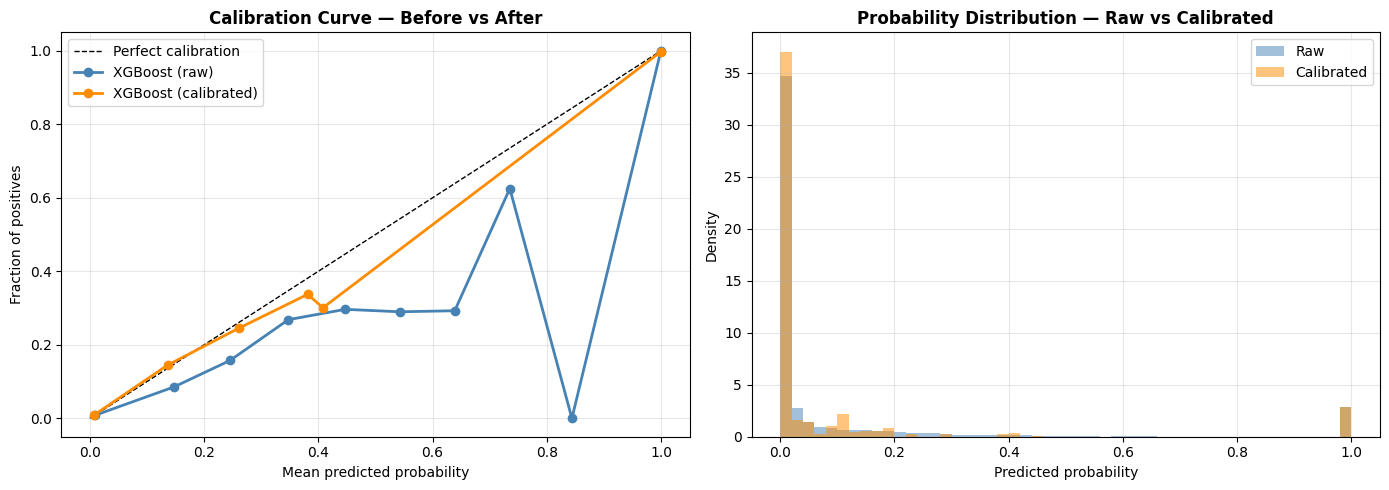

Calibration plot saved.

AUC after calibration : 0.9754
AUC before calibration: 0.9758

Generating p_clinical for full dataset...
p_clinical saved: (14998, 2)

p_clinical stats:
count    14998.0000
mean         0.0843
std          0.2354
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0310
max          1.0000
Name: p_clinical, dtype: float64

Clinical model complete. Ready for late fusion.


In [18]:
# ============================================================
# STEP 13: PROBABILITY CALIBRATION + SAVE p_clinical
# ============================================================
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('outputs', exist_ok=True)

print("=" * 60)
print("STEP 13: PROBABILITY CALIBRATION")
print("=" * 60)

# --- 13.1 Calibrate manually using isotonic regression ---
# (avoids sklearn/XGBoost 1.7.6 compatibility issue with CalibratedClassifierCV)
raw_val_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(raw_val_proba, y_val)
print("Isotonic calibration fitted on validation set.")

# --- 13.2 Apply to test set ---
raw_proba        = xgb_model.predict_proba(X_test_scaled)[:, 1]
calibrated_proba = iso_reg.predict(raw_proba)

print(f"\nRaw probabilities        — Mean: {raw_proba.mean():.4f} | Std: {raw_proba.std():.4f}")
print(f"Calibrated probabilities — Mean: {calibrated_proba.mean():.4f} | Std: {calibrated_proba.std():.4f}")
print(f"Actual positive rate     : {y_test.mean():.4f}")

# --- 13.3 Calibration curve plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraction_pos_raw, mean_pred_raw = calibration_curve(y_test, raw_proba,        n_bins=10)
fraction_pos_cal, mean_pred_cal = calibration_curve(y_test, calibrated_proba, n_bins=10)

axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
axes[0].plot(mean_pred_raw, fraction_pos_raw, 'o-', color='steelblue',
             lw=2, label='XGBoost (raw)')
axes[0].plot(mean_pred_cal, fraction_pos_cal, 'o-', color='darkorange',
             lw=2, label='XGBoost (calibrated)')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives')
axes[0].set_title('Calibration Curve — Before vs After', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(raw_proba,        bins=50, alpha=0.5, color='steelblue',
             label='Raw', density=True)
axes[1].hist(calibrated_proba, bins=50, alpha=0.5, color='darkorange',
             label='Calibrated', density=True)
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Probability Distribution — Raw vs Calibrated',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Calibration plot saved.")

# --- 13.4 AUC check ---
from sklearn.metrics import roc_auc_score
print(f"\nAUC after calibration : {roc_auc_score(y_test, calibrated_proba):.4f}")
print(f"AUC before calibration: {roc_auc_score(y_test, raw_proba):.4f}")

# --- 13.5 Save p_clinical for full dataset ---
print("\nGenerating p_clinical for full dataset...")
# Use test set only — held-out, never seen during training
test_raw_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
p_clinical     = iso_reg.predict(test_raw_proba)

p_clinical_df = pd.DataFrame({
    'p_clinical': p_clinical,
    'true_label': y_test.values
})

p_clinical_df.to_csv('outputs/p_clinical.csv', index=True, index_label='patient_idx')
print(f"p_clinical saved: {p_clinical_df.shape}")
print(f"\np_clinical stats:\n{p_clinical_df['p_clinical'].describe().round(4)}")
print("\nClinical model complete. Ready for late fusion.")

In [19]:
# ============================================================
# FINAL STEP: SAVE ALL ARTEFACTS NEEDED BY THE WEBAPP
# Run this ONCE after all training is complete.
# ============================================================
import joblib
import json
import os

os.makedirs('outputs/webapp_artefacts', exist_ok=True)

# 1. Save the XGBoost model
joblib.dump(xgb_model, 'outputs/webapp_artefacts/clinical_xgb_model.joblib')

# 2. Save the isotonic calibrator
joblib.dump(iso_reg, 'outputs/webapp_artefacts/clinical_iso_calibrator.joblib')

# 3. Save the TF-IDF vectoriser
joblib.dump(tfidf, 'outputs/webapp_artefacts/clinical_tfidf.joblib')

# 4. Save the SVD transformer
joblib.dump(svd, 'outputs/webapp_artefacts/clinical_svd.joblib')

# 5. Save the StandardScaler
joblib.dump(scaler, 'outputs/webapp_artefacts/clinical_scaler.joblib')

# 6. Save the metabolic_index normalisation values
# These MUST come from the training data only (df before the train/test split)
# We use df_encoded which still has all rows at that point in the notebook
metabolic_norm_params = {
    'hba1c_min':   float(df_encoded['hbA1c_level'].min()),
    'hba1c_max':   float(df_encoded['hbA1c_level'].max()),
    'glucose_min': float(df_encoded['blood_glucose_level'].min()),
    'glucose_max': float(df_encoded['blood_glucose_level'].max()),
    'bmi_lower':   float(bmi_lower),
    'bmi_upper':   float(bmi_upper),
    'glucose_lower': float(glucose_lower),
    'glucose_upper': float(glucose_upper)
}
with open('outputs/webapp_artefacts/clinical_norm_params.json', 'w') as f:
    json.dump(metabolic_norm_params, f, indent=2)

# 7. Save the exact feature order the model expects
feature_order = X_combined.columns.tolist()
with open('outputs/webapp_artefacts/clinical_feature_order.json', 'w') as f:
    json.dump(feature_order, f, indent=2)

# 8. Save the SVD readable label mapping for SHAP display
with open('outputs/webapp_artefacts/clinical_svd_labels.json', 'w') as f:
    json.dump(svd_labels, f, indent=2)

# 9. Save the numerical column indices (for the scaler)
with open('outputs/webapp_artefacts/clinical_numerical_cols.json', 'w') as f:
    json.dump(numerical_cols, f, indent=2)

# Verify everything saved
print("=" * 50)
print("WEBAPP ARTEFACTS SAVED SUCCESSFULLY")
print("=" * 50)
for fname in os.listdir('outputs/webapp_artefacts'):
    fpath = os.path.join('outputs/webapp_artefacts', fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:<50} {size_kb:>8.1f} KB")

print("\nAll artefacts ready. Copy the webapp_artefacts/ folder to your webapp.")

WEBAPP ARTEFACTS SAVED SUCCESSFULLY
  clinical_feature_order.json                             1.0 KB
  clinical_iso_calibrator.joblib                          1.0 KB
  clinical_norm_params.json                               0.2 KB
  clinical_numerical_cols.json                            0.1 KB
  clinical_scaler.joblib                                  1.1 KB
  clinical_svd.joblib                                    40.6 KB
  clinical_svd_labels.json                                1.4 KB
  clinical_tfidf.joblib                                   8.0 KB
  clinical_xgb_model.joblib                             464.9 KB

All artefacts ready. Copy the webapp_artefacts/ folder to your webapp.
